In [2]:
import joblib

import umap
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import pandas as pd
 
from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset, load_ovr_inference_memmap
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths
from birdclef_2026_ml.configs import artifact_stem
from birdclef_2026_ml.training.eval import plot_confusion_matrix, eval_multiclass_singlelabel
from birdclef_2026_ml.models.hierarchical import combine_soft_proba

paths = load_project_paths()

init_notebook()

In [3]:
def plot_class_name_confusions(
    true_labels,
    pred_labels,
    le_primary_label,
    primary_to_class,
    class_names,
    cmap="Blues",
):
    true_labels = np.asarray(true_labels)
    pred_labels = np.asarray(pred_labels)
    true_idx = le_primary_label.transform(true_labels)

    # Keep only class_names that actually have samples
    valid_class_names = []

    for class_name in class_names:
        idx = np.where(primary_to_class == class_name)[0]
        mask = np.isin(true_idx, idx)

        if np.any(mask):
            valid_class_names.append(class_name)

    n = len(valid_class_names)

    if n == 0:
        raise ValueError("No samples found for any class_name.")

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(5 * n, 5),
        squeeze=False,
    )

    for ax, class_name in zip(axes[0], valid_class_names):
        idx = np.where(primary_to_class == class_name)[0]
        mask = np.isin(true_idx, idx)

        labels = le_primary_label.inverse_transform(idx)

        plot_confusion_matrix(
            true_labels[mask],
            pred_labels[mask],
            labels=labels,
            annot=False,
            ax=ax,
            cmap=cmap,
            plot_labels=False,
        )

        ax.set_title(class_name)

    plt.tight_layout()

    return fig

In [4]:
le_class_name = joblib.load(paths.label_encoders_dir / "class_name.joblib")
le_primary_label = joblib.load(paths.label_encoders_dir / "primary_label.joblib")

primary_to_class = le_class_name.inverse_transform(np.load(paths.primary_to_class / "primary_to_class.npy"))

## 5 seconds chunks

In [5]:
run_name = "run_chunks_overlap"
experiment_name = "sgd_baseline"

dataset = load_memmap_dataset(run_name=run_name, reduced=True, soundscape=False)
experiment_dir = paths.experiment_dir(run_name, experiment_name)

val_idx = np.load(experiment_dir / "val_indices.npy")
inference_dir = experiment_dir / "inference"
inference_probas = load_ovr_inference_memmap(inference_dir, "sgdclassifier_ovr", dual=True)

In [16]:
val_true_class_name = le_class_name.inverse_transform(dataset.y[val_idx, 0])
val_true_primary_label = le_primary_label.inverse_transform(dataset.y[val_idx, 1])

val_proba_class_name = inference_probas.class_name[val_idx, :]
val_proba_primary_label = inference_probas.primary_label[val_idx, :]
val_soft_proba_primary_label = combine_soft_proba(val_proba_class_name, val_proba_primary_label)

val_pred_class_name = le_class_name.inverse_transform(np.argmax(val_proba_class_name, axis=1))
val_pred_primary_label = le_primary_label.inverse_transform(np.argmax(val_proba_primary_label, axis=1))
val_soft_pred_primary_label = le_primary_label.inverse_transform(np.argmax(val_soft_proba_primary_label, axis=1))

In [27]:
np.unique(le_class_name.transform(val_true_class_name))

array([0, 1, 2, 3])

In [29]:
val_proba_class_name

array([[9.97099698e-01, 2.15356160e-04, 9.98945959e-01, 2.35992356e-01,
        9.86122469e-01],
       [9.99817481e-01, 1.07419899e-05, 9.98424294e-01, 6.38883075e-01,
        9.12058279e-01],
       [9.98900497e-01, 2.02300421e-04, 9.98227350e-01, 4.77223195e-01,
        9.08268189e-01],
       ...,
       [7.13437234e-01, 3.23697868e-01, 6.68060694e-01, 5.01636438e-01,
        8.21799756e-01],
       [8.52593674e-01, 4.47456326e-01, 6.81497626e-01, 4.01002079e-01,
        6.68923658e-01],
       [9.63606185e-01, 1.22629222e-01, 7.83258688e-01, 1.87575235e-01,
        7.16148762e-01]], shape=(66387, 5))

In [ ]:
metrics_class_name = eval_multiclass_singlelabel(
    le_class_name.transform(val_true_class_name),
    le_class_name.transform(val_pred_class_name),
    val_proba_class_name,
    np.arange(len(le_class_name.classes_))
)

metrics_raw_primary_label = eval_multiclass_singlelabel(
    le_primary_label.transform(val_true_primary_label),
    le_primary_label.transform(val_pred_primary_label),
    val_proba_primary_label,
    np.arange(len(le_primary_label.classes_))
)

metrics_soft_primary_label = eval_multiclass_singlelabel(
    le_primary_label.transform(val_true_primary_label),
    le_primary_label.transform(val_soft_pred_primary_label),
    val_soft_proba_primary_label,
    np.arange(len(le_primary_label.classes_))
)

/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


n_samples=66387
accuracy=0.5037
balanced_accuracy=0.7257
top2_accuracy=0.6128
top3_accuracy=0.6781
macro_precision=0.2173
macro_recall=0.5806
macro_f1=0.1662
macro_roc_auc=0.9204


/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


n_samples=66387
accuracy=0.0039
balanced_accuracy=0.0264
top2_accuracy=0.0029
top3_accuracy=0.0057
macro_precision=0.0027
macro_recall=0.0257
macro_f1=0.0043
macro_roc_auc=0.8262


/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


n_samples=66387
accuracy=0.0039
balanced_accuracy=0.0264
top2_accuracy=0.0029
top3_accuracy=0.0057
macro_precision=0.0027
macro_recall=0.0257
macro_f1=0.0043
macro_roc_auc=0.8262


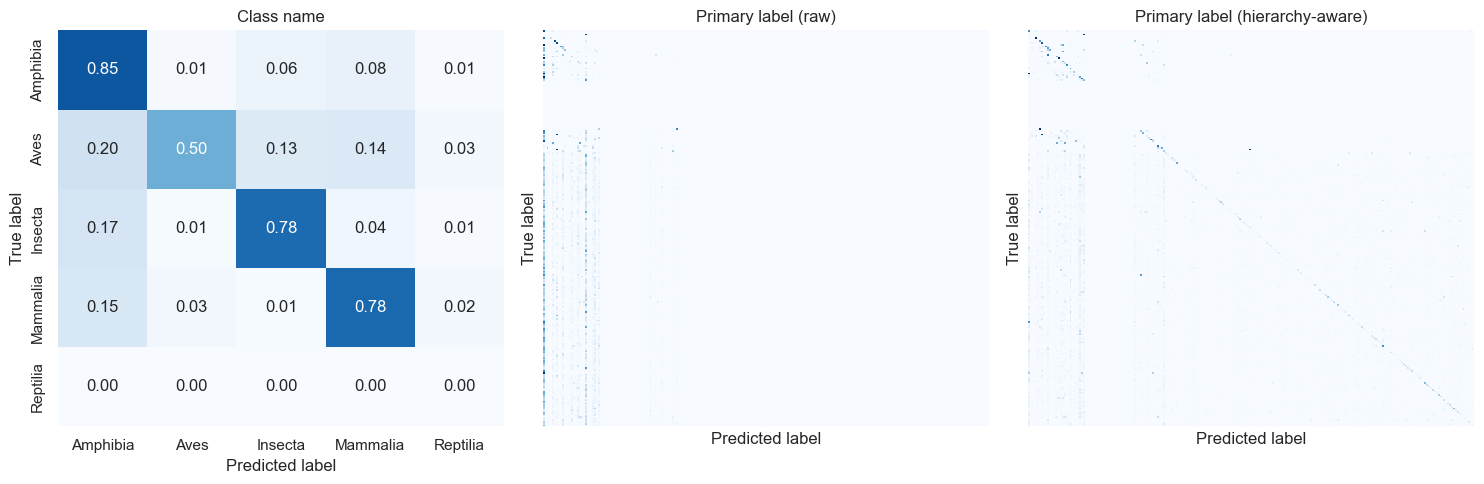

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_confusion_matrix(
    val_true_class_name,
    val_pred_class_name,
    labels=le_class_name.classes_,
    annot=True,
    ax=axes[0],
    cmap="Blues",
    plot_labels=True
)

plot_confusion_matrix(
    val_true_primary_label,
    val_pred_primary_label,
    labels=le_primary_label.classes_,
    annot=False,
    ax=axes[1],
    cmap="Blues"
)

plot_confusion_matrix(
    val_true_primary_label,
    val_soft_pred_primary_label,
    labels=le_primary_label.classes_,
    annot=False,
    ax=axes[2],
    cmap="Blues"
)

axes[0].set_title("Class name")
axes[1].set_title("Primary label (raw)")
axes[2].set_title("Primary label (hierarchy-aware)")

plt.tight_layout()
fig.savefig("plots/evaluation/run_chunks_overlap_cm_all.jpg", dpi=150, bbox_inches="tight")

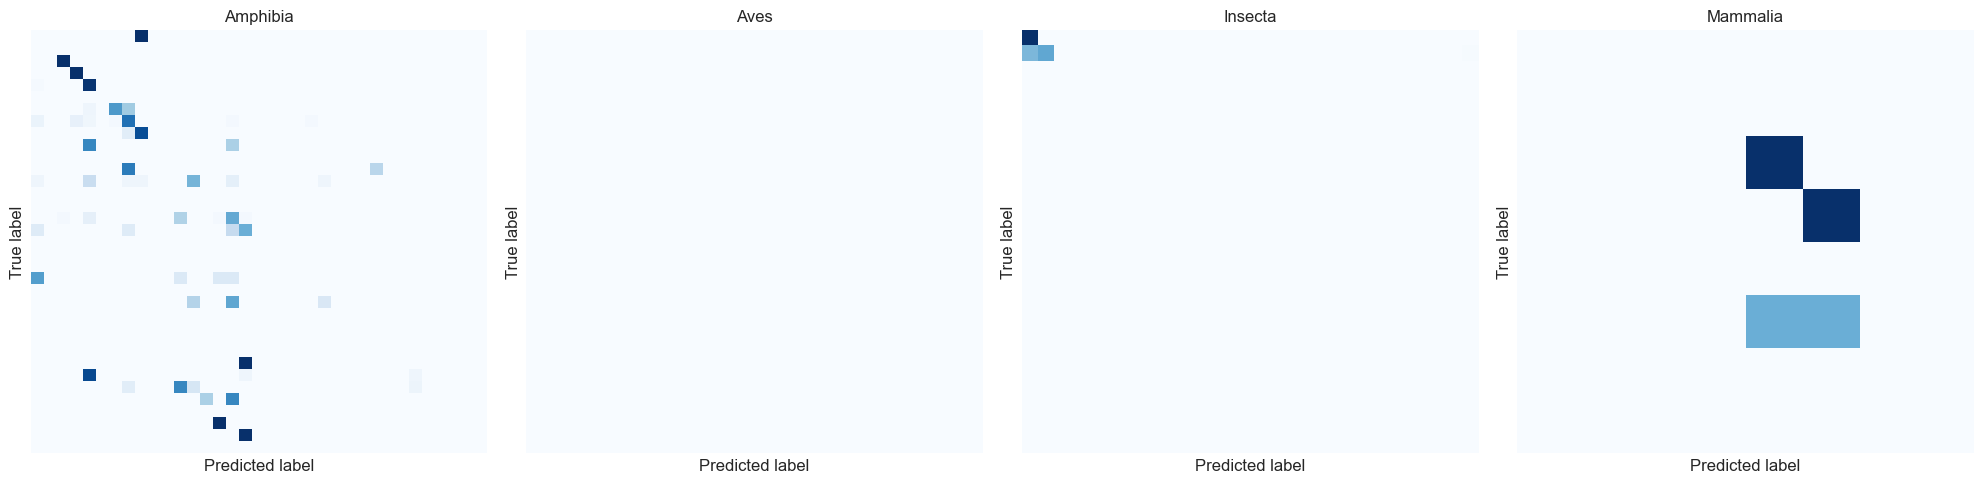

In [ ]:
fig = plot_class_name_confusions(
    val_true_primary_label,
    val_pred_primary_label,
    le_primary_label,
    primary_to_class,
    class_names=le_class_name.classes_,
)
fig.savefig("plots/evaluation/run_chunks_overlap_cm_per_class_raw.jpg", dpi=150, bbox_inches="tight")

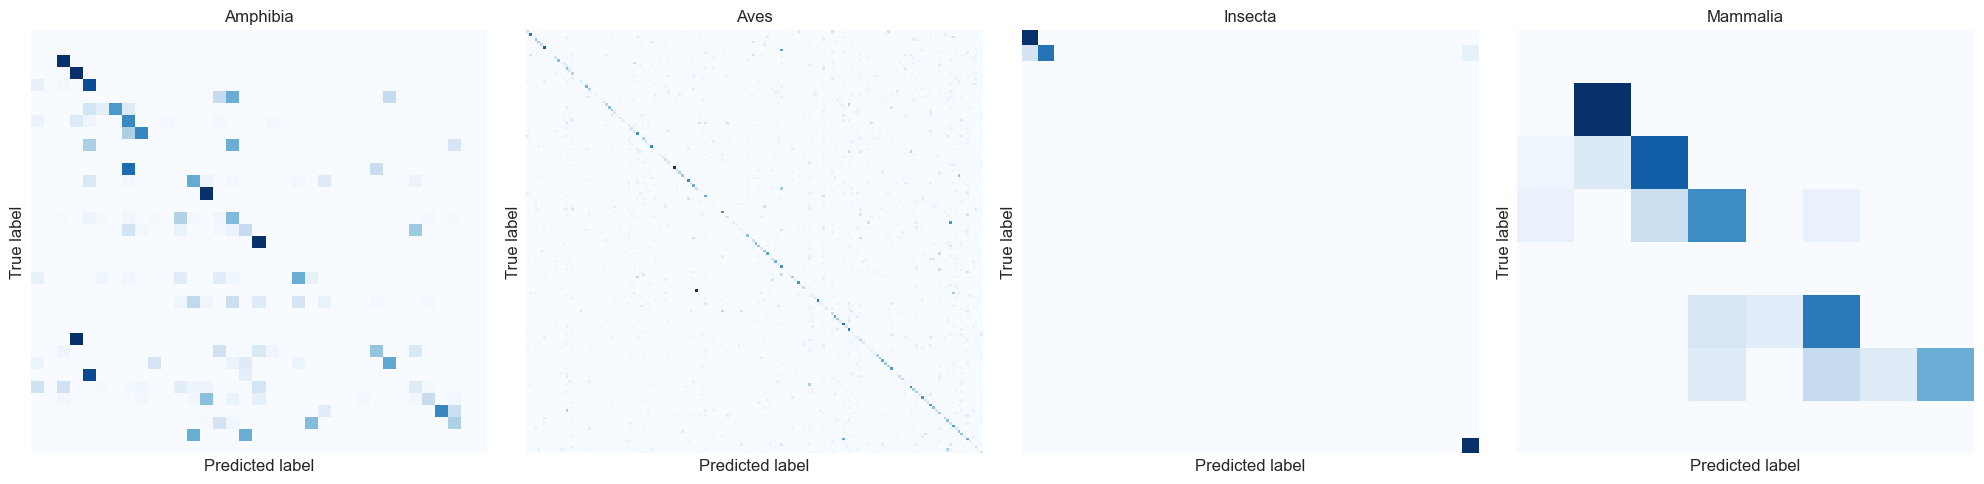

In [36]:
fig=plot_class_name_confusions(
    val_true_primary_label,
    val_soft_pred_primary_label,
    le_primary_label,
    primary_to_class,
    class_names=le_class_name.classes_,
)
fig.savefig("plots/evaluation/run_chunks_overlap_cm_per_class_soft.jpg", dpi=150, bbox_inches="tight")

## MIL

In [37]:
run_name = "run_mil"
experiment_name = "sgd_baseline"

dataset = load_memmap_dataset(run_name=run_name, reduced=True, soundscape=False)
experiment_dir = paths.experiment_dir(run_name, experiment_name)

val_proba_primary_label = np.load(experiment_dir / "clean_audio" / "val_proba.npy")
val_primary_label = np.load(experiment_dir / "clean_audio" / "val_bag_labels.npy")
val_pred_primary_label = le_primary_label.inverse_transform(val_proba_primary_label.argmax(axis=1))

val_true_primary_label = np.load(experiment_dir / "clean_audio" / "val_bag_labels.npy")
val_true_primary_label = le_primary_label.inverse_transform(val_true_primary_label)

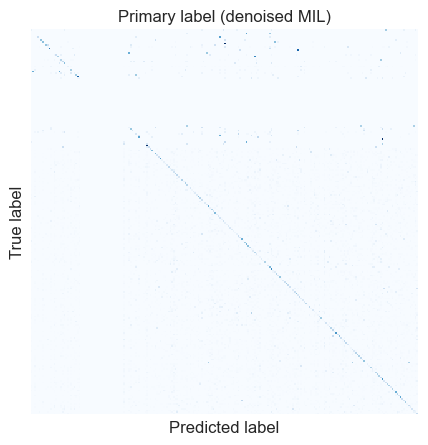

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

plot_confusion_matrix(
    val_true_primary_label,
    val_pred_primary_label,
    labels=le_primary_label.classes_,
    annot=False,
    ax=ax,
    cmap="Blues"
)
ax.set_title("Primary label (denoised MIL)")
fig.savefig("plots/evaluation/run_mil_cm_all.jpg", dpi=150, bbox_inches="tight")

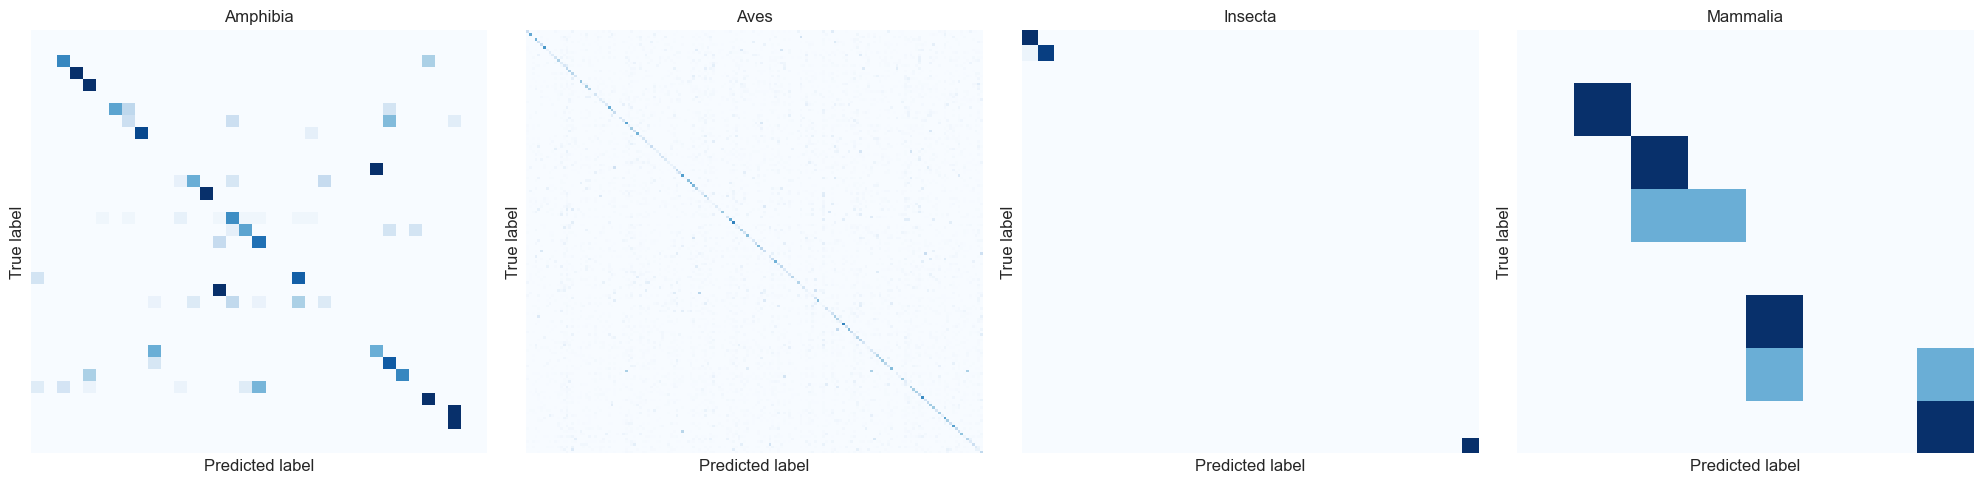

In [39]:
fig=plot_class_name_confusions(
    val_true_primary_label,
    val_pred_primary_label,
    le_primary_label,
    primary_to_class,
    class_names=le_class_name.classes_,
    cmap="Blues"
)
fig.savefig("plots/evaluation/run_mil_cm_per_class.jpg", dpi=150, bbox_inches="tight")